In [55]:
import os
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')

# 快速检查
print("数据形状:", df.shape)
print("\n前 5 行:")
print(df.head())
print("\n列名:")
print(df.columns.tolist())
print("\n目标变量统计:")
print(df['n_dielectric'].describe())

数据形状: (4764, 136)

前 5 行:
   n_dielectric  MagpieData minimum Number  MagpieData maximum Number  \
0      1.752064                       16.0                       19.0   
1      1.652859                        8.0                       23.0   
2      1.867858                        8.0                       40.0   
3      2.676887                        8.0                       25.0   
4      1.793232                        3.0                       27.0   

   MagpieData range Number  MagpieData mean Number  MagpieData avg_dev Number  \
0                      3.0                  17.500                   1.500000   
1                     15.0                  14.000                   6.000000   
2                     32.0                  23.000                  15.000000   
3                     17.0                  14.000                   7.333333   
4                     24.0                   9.875                   5.312500   

   MagpieData mode Number  MagpieData minimum Me

数据形状   4764行 * 136列  
max       62.062998 
中位数     2.060778
大部分数据偏小 少部分数据极大 右侧拖出长尾巴 右偏分布


In [60]:
# 分离特征和目标
X = df.drop('n_dielectric', axis=1)  # 所有列除了目标
y = np.log1p(df['n_dielectric'])                # 目标列

print(f"特征矩阵 X: {X.shape}")
print(f"目标向量 y: {y.shape}")

# 划分训练集和测试集（80% 训练，20% 测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% 作为测试集
    random_state=42     # 固定随机种子，保证结果可复现
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

特征矩阵 X: (4764, 135)
目标向量 y: (4764,)

训练集大小: 3811
测试集大小: 953


In [93]:
# 创建决策树模型
dt = DecisionTreeRegressor(max_depth = 4 ,random_state= 42)
# 训练模型
dt.fit(X_train, y_train)

print("模型训练完成！")
print(f"树的深度: {dt.get_depth()}")
print(f"叶子节点数: {dt.get_n_leaves()}")

模型训练完成！
树的深度: 4
叶子节点数: 16


In [94]:
# 在训练集和测试集上分别预测
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# 计算评估指标
def evaluate(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{dataset_name} 评估结果")
    print(f"{'='*50}")
    print(f"MSE  (均方误差):     {mse:.4f}")
    print(f"RMSE (均方根误差):   {rmse:.4f}")
    print(f"MAE  (平均绝对误差): {mae:.4f}")
    print(f"R²   (决定系数):     {r2:.4f}")
    return mse, rmse, mae, r2

# 评估
train_metrics = evaluate(y_train, y_train_pred, "训练集")
test_metrics = evaluate(y_test, y_test_pred, "测试集")


训练集 评估结果
MSE  (均方误差):     0.0369
RMSE (均方根误差):   0.1921
MAE  (平均绝对误差): 0.1070
R²   (决定系数):     0.5456

测试集 评估结果
MSE  (均方误差):     0.0328
RMSE (均方根误差):   0.1811
MAE  (平均绝对误差): 0.1077
R²   (决定系数):     0.5172


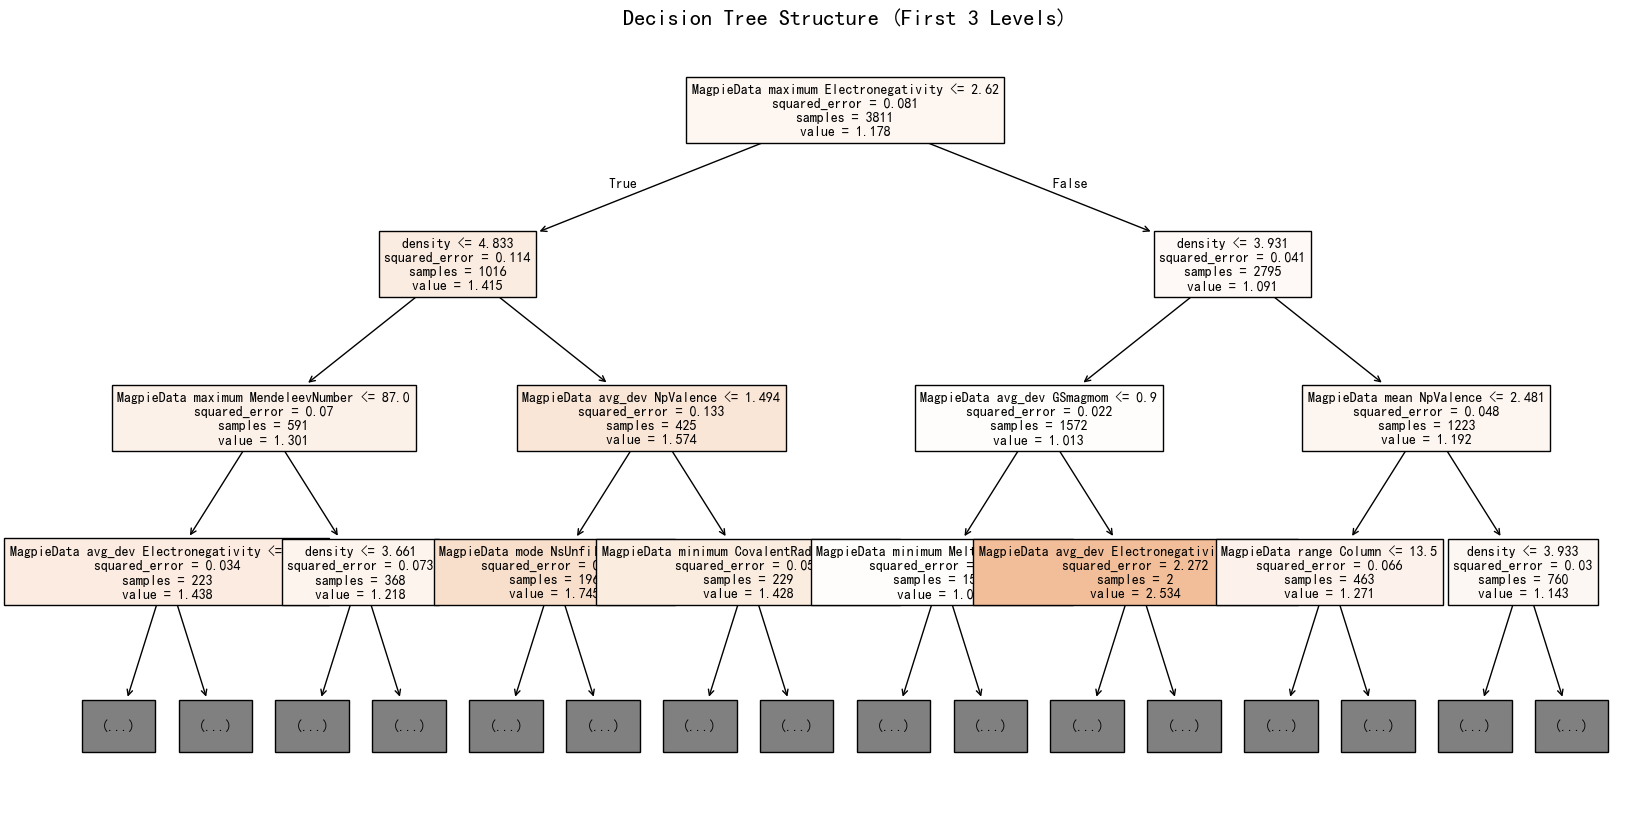

决策树可视化已保存到 day01_tree_structure.png


In [98]:
# 创建图形文件夹
import os

# 可视化决策树（只画前 3 层，不然太复杂）
plt.figure(figsize=(20, 10))
plot_tree(
    dt, 
    max_depth=3,              # 只显示前 3 层
    filled=True,              # 用颜色填充
    feature_names=X.columns,  # 显示特征名
    fontsize=10
)
plt.title("Decision Tree Structure (First 3 Levels)", fontsize=16)
plt.savefig('../figures/day01_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("决策树可视化已保存到 day01_tree_structure.png")

# Day 1 学习日志

## 1. 决策树是怎么工作的？ 
    从根节点开始 然后每个节点依据特征以及 阈值不断做二分类判断  ，优先选择 分类后数据更纯净的特征逐层划分 直到输出预测的类别或者数值
## 2. 评估指标理解

- MSE 和 R² 哪个越大越好？
  答：MSE是指均方误差 越小模型的效果越好 R²是决定系数 越大模型的拟合效果越好 

- 我的模型测试集 R² = ？（填你的实际结果）
  这个结果算好还是差？
  答： (R^2 > 0.8)：效果优秀
      (0.6 < R^2 < 0.8)：效果良好
      (0.4 < R^2 < 0.6)：效果一般
      (R^2 < 0.4)：效果较差
      一开始是负数 但是经过log变换之后变为正数 但是依旧很小 0.5 效果一般 (更改树的深度)

## 3. 今天遇到的问题和解决方法
问题 1：数据最大值远大于大部分样本，分布不均衡
解决：先统计、可视化识别异常值，为后续数据预处理做准备。
问题 2：最开始的R²是一个 负数
解决：按 可得到的两个原因有两种 存在过拟合现象 还有就是数据分布太极端导致 均值是2.43 最大值却有62.06 对目标的数据做log变换
      当目标变量的最大值 / 最小值 > 30 倍时，加 np.log1p() 把尾巴压平。
